In [1]:
# code stolen from:
# https://github.com/keras-team/keras-io/blob/master/examples/structured_data/structured_data_classification_from_scratch.py

In [2]:
"""
## Setup
"""

import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers


In [3]:
"""
## Preparing the data
Let's download the data and load it into a Pandas dataframe:
"""

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)


In [4]:
"""
The dataset includes 303 samples with 14 columns per sample (13 features, plus the target
label):
"""

dataframe.shape

(303, 14)

In [5]:
"""
Here's a preview of a few samples:
"""

dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


# wide & deep exploration

question                                               | completed
-------------------------------------------------------|------------
categorical vbls with unseen values in test set?       | no
wide & deep model?                                     | yes
embedded categorical variables                         | no
crossed categorical variables in dataset first         | no
normalize numeric variables in dataset first           | yes

In [6]:
experiment_data = dataframe[['target','slope','age','sex','thal','restecg']].copy()

experiment_data['sex'] = np.select( condlist = [ experiment_data['sex'] == 0,
                                                 experiment_data['sex'] == 1
                                               ],
                                    choicelist = [ 'female', 'male' ],
                                    default = None
                                  )

experiment_data['restecg'] = 'ecg' + experiment_data['restecg'].astype(str) 

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg
46,0,1,65,female,normal,ecg2
286,0,1,45,male,normal,ecg2
195,1,1,52,male,reversible,ecg0
183,1,3,56,male,reversible,ecg2
38,1,2,55,male,reversible,ecg0
88,0,2,51,male,normal,ecg2
15,0,1,57,male,normal,ecg0
16,0,3,48,male,reversible,ecg0
163,0,1,46,female,normal,ecg0
12,1,2,56,male,fixed,ecg2


In [7]:
# prepare features for model:

# normalize numeric variables:
experiment_data['slope'] = ( experiment_data['slope'] - np.mean(experiment_data['slope']) ) / np.std(experiment_data['slope'])  # normalize "slope" 
experiment_data['age'] = ( experiment_data['age'] - np.mean(experiment_data['age']) ) / np.std(experiment_data['age'])  # normalize "age" 

# create crossed features:
features_to_cross = ['sex','thal','restecg']
import itertools
for combination in itertools.combinations(features_to_cross,2):
    experiment_data[ combination[0]+'_x_'+combination[1] ] = experiment_data[ combination[0] ] + '_' + experiment_data[ combination[1] ]

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg,sex_x_thal,sex_x_restecg,thal_x_restecg
46,0,-0.957863,1.156026,female,normal,ecg2,female_normal,female_ecg2,normal_ecg2
26,0,-0.957863,0.378376,female,normal,ecg0,female_normal,female_ecg0,normal_ecg0
14,0,-0.957863,-0.288181,male,reversible,ecg0,male_reversible,male_ecg0,reversible_ecg0
256,0,-0.957863,0.711654,female,normal,ecg2,female_normal,female_ecg2,normal_ecg2
0,0,2.284959,0.933840,male,fixed,ecg2,male_fixed,male_ecg2,fixed_ecg2
289,0,-0.957863,1.822583,female,normal,ecg2,female_normal,female_ecg2,normal_ecg2
120,0,0.663548,0.489468,female,normal,ecg0,female_normal,female_ecg0,normal_ecg0
45,0,-0.957863,-1.176924,male,normal,ecg2,male_normal,male_ecg2,normal_ecg2
107,1,0.663548,0.600561,male,reversible,ecg2,male_reversible,male_ecg2,reversible_ecg2
62,0,0.663548,0.822747,male,reversible,ecg0,male_reversible,male_ecg0,reversible_ecg0


In [13]:
from tensorflow.keras.layers.experimental.preprocessing import CategoryEncoding
from tensorflow.keras.layers.experimental.preprocessing import StringLookup

def encode_string_categorical_feature(feature, name, dataset):
     # this function from https://github.com/keras-team/keras-io/blob/master/examples/structured_data/structured_data_classification_from_scratch.py
    
    # Create a StringLookup layer which will turn strings into integer indices
    index = StringLookup()

    # Prepare a Dataset that only yields our feature
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))

    # Learn the set of possible string values and assign them a fixed integer index
    index.adapt(feature_ds)

    # Turn the string input into integer indices
    encoded_feature = index(feature)

    # Create a CategoryEncoding for our integer indices
    encoder = CategoryEncoding(output_mode="binary")

    # Prepare a dataset of indices
    feature_ds = feature_ds.map(index)

    # Learn the space of possible indices
    encoder.adapt(feature_ds)

    # Apply one-hot encoding to our indices
    encoded_feature = encoder(encoded_feature)
    
    return encoded_feature

In [ ]:
# one hot encode the categorical variables:
#experiment_data = pd.get_dummies( 
#                experiment_data,
#                columns = ['sex','thal','restecg','sex_x_thal','sex_x_restecg','thal_x_restecg']
#              )
#experiment_data.sample(10)

In [10]:
# train/validation 80%/20% split: 
val_data = experiment_data.sample(frac=0.2, random_state=1337)
train_data = experiment_data.drop(val_data.index)

print(
    "Using %d samples for training and %d for validation"
    % (len(train_data), len(val_data))
)

Using 242 samples for training and 61 for validation


In [14]:
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("target")    # pull out y (response) column 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train_data)
val_ds = dataframe_to_dataset(val_data)

# batch the datasets:
train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)

In [15]:
# Numerical features
slope = keras.Input(shape=(1,), name='slope')
age = keras.Input(shape=(1,), name='age')

# Categorical features:
sex = keras.Input(shape=(1,), name='sex', dtype='string')
sex_encoded = encode_string_categorical_feature( feature = sex, 
                                                    name = 'sex', 
                                                 dataset = train_ds
                                               )
thal = keras.Input(shape=(1,), name='thal', dtype='string')
thal_encoded = encode_string_categorical_feature( feature = thal, 
                                                     name = 'thal', 
                                                  dataset = train_ds
                                               )
restecg = keras.Input(shape=(1,), name='restecg', dtype='string')
restecg_encoded = encode_string_categorical_feature( feature = restecg, 
                                                        name = 'restecg', 
                                                     dataset = train_ds
                                               )

sex_x_thal = keras.Input(shape=(1,), name='sex_x_thal', dtype='string')
sex_x_thal_encoded = encode_string_categorical_feature( feature = sex_x_thal,
                                                        name = 'sex_x_thal',   
                                                        dataset = train_ds
                                                      )

sex_x_restecg = keras.Input(shape=(1,), name='sex_x_restecg', dtype='string')
sex_x_restecg_encoded = encode_string_categorical_feature( feature = sex_x_restecg,
                                                           name = 'sex_x_restecg',       
                                                           dataset = train_ds 
                                                         )

thal_x_restecg = keras.Input(shape=(1,), name='thal_x_restecg', dtype='string')
thal_x_restecg_encoded = encode_string_categorical_feature( feature = thal_x_restecg, 
                                                            name = 'thal_x_restecg',
                                                            dataset = train_ds
                                                          )

all_inputs = [
   slope,
   age,
   sex,
   thal,
   restecg, 
   sex_x_thal,
   sex_x_restecg,
   thal_x_restecg, 
]

In [23]:
all_features = layers.concatenate(
    [
        slope,
        age,
        sex_encoded,
        thal_encoded,
        restecg_encoded,
        sex_x_thal_encoded,
        sex_x_restecg_encoded,
        thal_x_restecg_encoded 
    ]
)

features_for_wide = layers.concatenate( 
    [ 
        sex_encoded,
        thal_encoded,
        restecg_encoded,
        sex_x_thal_encoded,
        sex_x_restecg_encoded,
        thal_x_restecg_encoded         
    ],
    name = 'inputs_for_wide'
)

features_for_deep = layers.concatenate( 
    [ 
        sex_encoded, 
        age,
        slope,
    ],
    name = 'inputs_for_deep'
)

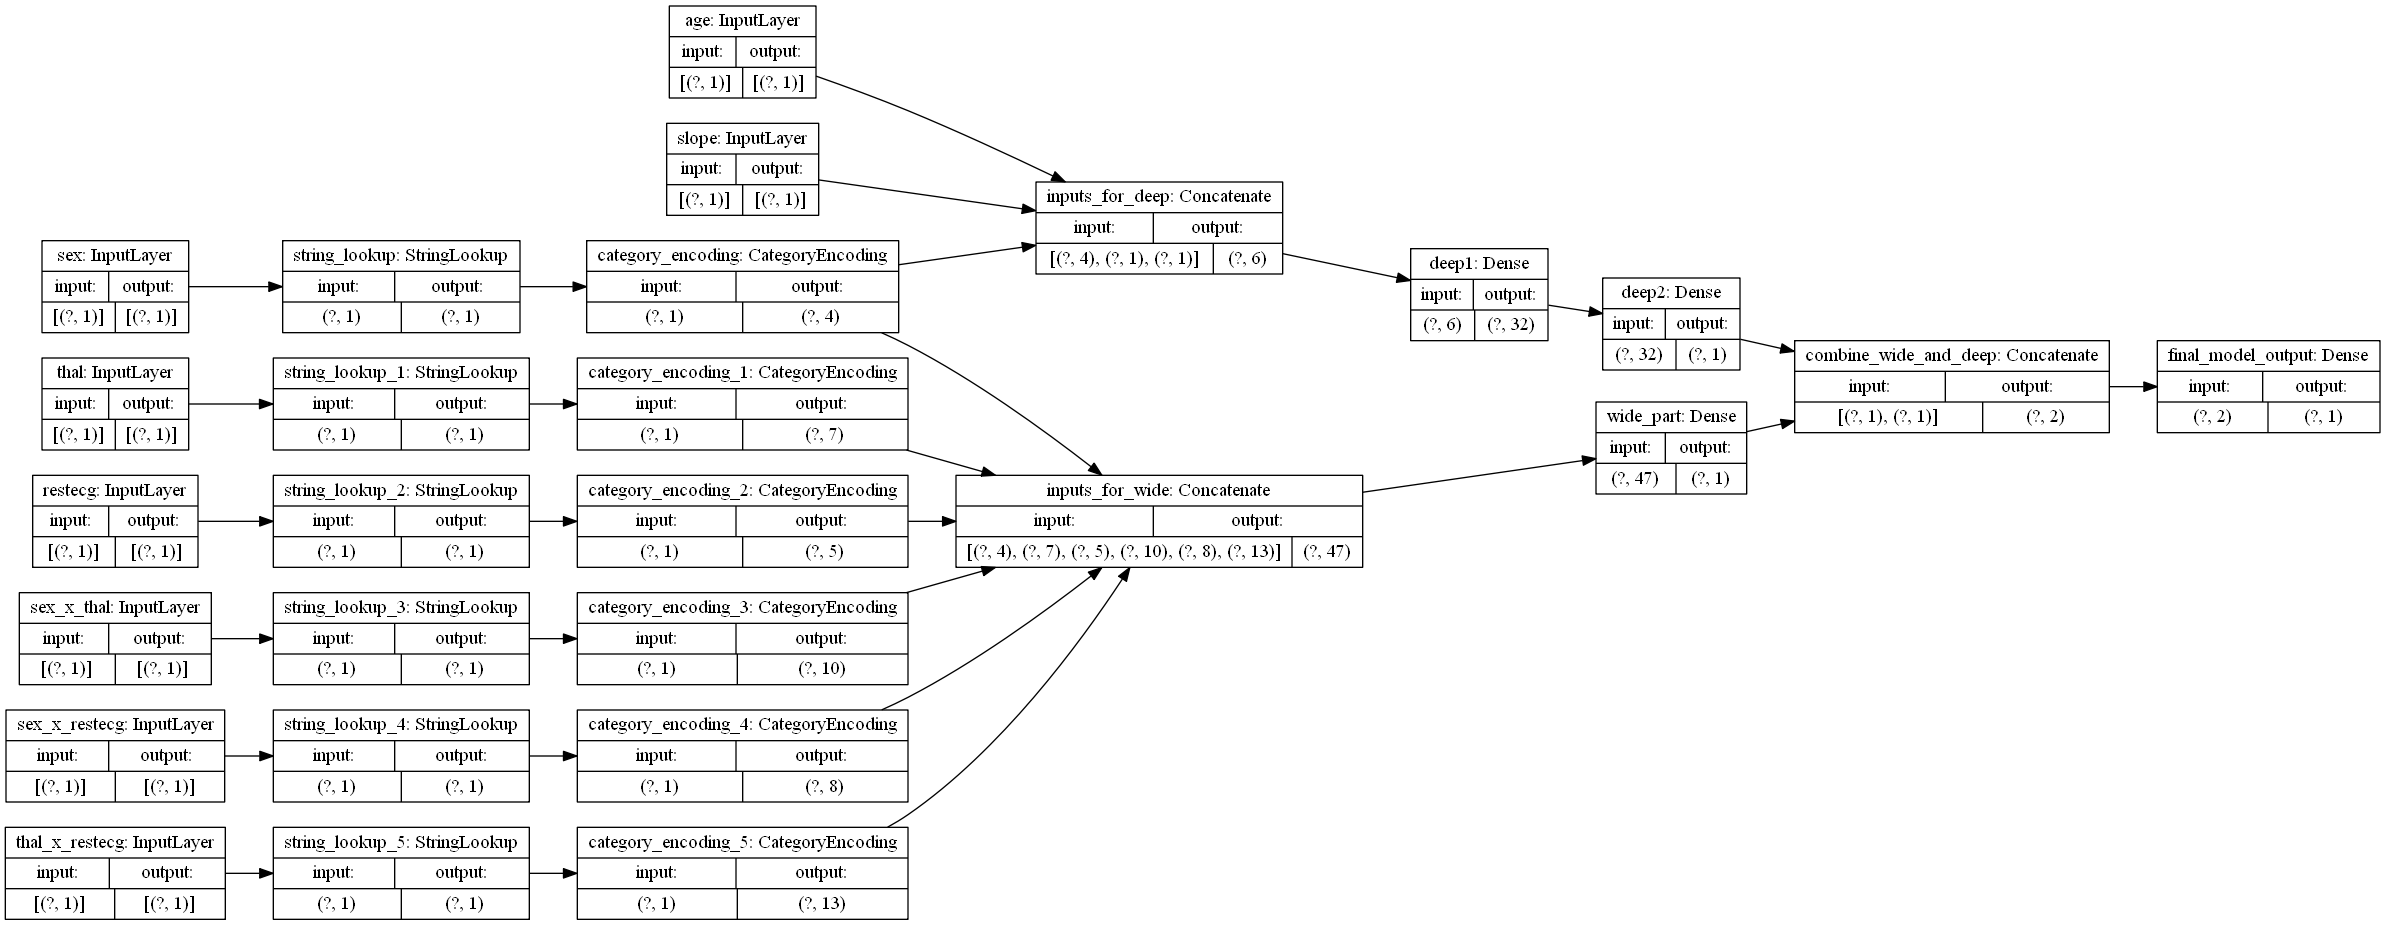

In [25]:
wide_output = layers.Dense(1, 
                           activation='sigmoid',
                           name = 'wide_part',
                          )(features_for_wide)

deep_layer1 = layers.Dense( 32, 
                            activation='relu',
                            name = 'deep1' 
                          )(features_for_deep)
deep_output = layers.Dense( 1, 
                            activation='sigmoid',
                            name = 'deep2'
                          )(deep_layer1)

combine_model_outputs = layers.concatenate( 
    [ 
        wide_output,
        deep_output,
    ],
    name = 'combine_wide_and_deep'
)

final_output = layers.Dense( 1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(combine_model_outputs)

model = keras.Model(all_inputs, final_output)
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [ ]:
#x = layers.Dense(32, activation="relu")(all_features)
#x = layers.Dropout(0.5)(x)
#output = layers.Dense(1, activation="sigmoid")(x)
#model = keras.Model(all_inputs, output)
#model.compile("adam", "binary_crossentropy", metrics=["accuracy"])
#keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [ ]:
model.summary()

In [18]:
model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
8/8 [==============================] - 1s 97ms/step - loss: 0.6171 - accuracy: 0.7149 - val_loss: 0.5761 - val_accuracy: 0.7705
Epoch 2/50
8/8 [==============================] - 0s 10ms/step - loss: 0.6142 - accuracy: 0.7149 - val_loss: 0.5733 - val_accuracy: 0.7705
Epoch 3/50
8/8 [==============================] - 0s 10ms/step - loss: 0.6117 - accuracy: 0.7149 - val_loss: 0.5704 - val_accuracy: 0.7705
Epoch 4/50
8/8 [==============================] - 0s 11ms/step - loss: 0.6089 - accuracy: 0.7149 - val_loss: 0.5677 - val_accuracy: 0.7705
Epoch 5/50
8/8 [==============================] - 0s 10ms/step - loss: 0.6064 - accuracy: 0.7149 - val_loss: 0.5649 - val_accuracy: 0.7705
Epoch 6/50
8/8 [==============================] - 0s 9ms/step - loss: 0.6038 - accuracy: 0.7149 - val_loss: 0.5621 - val_accuracy: 0.7705
Epoch 7/50
8/8 [==============================] - 0s 10ms/step - loss: 0.6014 - accuracy: 0.7149 - val_loss: 0.5592 - val_accuracy: 0.7705
Epoch 8/50
8/8 [============

In [ ]:
# can extract the weights from model.layers:
model.layers